## Baseline Model Training


## Model
    Logistic Regression
    Decision Tree
    Random Forest
    Support Vector Machine
    K-Nearest Neighbors
    Naive Bayes

## For each model report
    Accuracy
    Precision
    Recall
    F1-score
    ROC-AUC
    Confusion Matrix
    Cross-validation score
    Training time
    Prediction time

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt

## 2. Load the Preprocessed Dataset

`02_Preprocessing_Fixed.ipynb`: duplicates
removed, outliers clipped (bug-free IQR), missing values properly imputed (median for numeric,
most-frequent for categorical), and scaling fit only on the training set. No further cleaning is needed

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(X_train.shape, X_test.shape)
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

(734, 28) (184, 28)
Missing values in X_train: 0
Missing values in X_test: 0


## 3. Define Candidate Models

Same six models as the original notebook — Logistic Regression, Decision Tree, Random Forest, SVM, KNN,
Naive Bayes — compared on identical preprocessed data.

In [3]:
from sklearn.ensemble import VotingClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Voting Classifier (SVM + LR)": VotingClassifier(
        estimators=[
            ("svm", SVC(probability=True, random_state=42)),
            ("lr", LogisticRegression(random_state=42, max_iter=1000))
        ],
        voting="soft"
    )
}

## 4. Evaluation Function

Same metrics as the original (Accuracy, Precision, Recall, F1, ROC-AUC, CV score), but cross-validation
now uses `StratifiedKFold` so each fold preserves the same class balance as the full training set —
plain `KFold` (used in the original) can produce folds with a skewed class ratio, especially with a
smaller dataset like this one.

In [4]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model):
    model.fit(X_train, y_train)

    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    auc = roc_auc_score(y_test, probability)

    cv = cross_val_score(
        model, X_train, y_train,
        cv=cv_strategy,
        scoring="accuracy"
    ).mean()

    return [accuracy, precision, recall, f1, auc, cv]

## 5. Run All Models

In [5]:
results = []

for name, model in models.items():
    metrics = evaluate_model(model)
    results.append([name] + metrics)

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "CV Score"]
)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV Score
3,Support Vector Machine,0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
6,Voting Classifier (SVM + LR),0.853261,0.831858,0.921569,0.874419,0.926710,0.822906
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
2,Random Forest,0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,KNN,0.831522,0.844660,0.852941,0.848780,0.902021,0.812012
5,Naive Bayes,0.826087,0.864583,0.813725,0.838384,0.893711,0.754748
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953


## 6. Hyperparameter Tuning the Best Model

identified the best-performing model family, we tune it with `GridSearchCV`
(using the same stratified CV strategy) rather than shipping untuned defaults.

In [6]:
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"]
    },
    "Decision Tree": {
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },
    "Support Vector Machine": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.1],
        "kernel": ["rbf", "linear"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    }
}

best_models = {}
best_cv_scores = {}

for name, model in models.items():
    if name in param_grids:
        print(f"Tuning {name}...")
        grid_search = GridSearchCV(
            model,
            param_grid=param_grids[name],
            cv=cv_strategy,
            scoring="accuracy",
            n_jobs=-1
        )
        grid_search.fit(X_train, y_train)
        best_models[name] = grid_search.best_estimator_
        best_cv_scores[name] = grid_search.best_score_
        print(f"  Best params: {grid_search.best_params_}")
        print(f"  Best CV accuracy: {grid_search.best_score_:.4f}\n")
    else:
        # For models without grid (Naive Bayes, Voting) just fit and score
        print(f"Evaluating {name} without GridSearch...")
        cv_score = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="accuracy").mean()
        model.fit(X_train, y_train)
        best_models[name] = model
        best_cv_scores[name] = cv_score
        print(f"  CV accuracy: {cv_score:.4f}\n")

# Create an ensemble of the top 3 models
print("Creating an ensemble of the top 3 models...")
top_3_names = sorted(best_cv_scores, key=best_cv_scores.get, reverse=True)[:3]
# Only use models that support predict_proba for soft voting if we wanted soft, but let's use hard voting to be safe
top_3_estimators = [(name, best_models[name]) for name in top_3_names]

from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(estimators=top_3_estimators, voting='soft')
ensemble_cv_score = cross_val_score(ensemble, X_train, y_train, cv=cv_strategy, scoring="accuracy").mean()
ensemble.fit(X_train, y_train)

best_models['Ensemble (Top 3)'] = ensemble
best_cv_scores['Ensemble (Top 3)'] = ensemble_cv_score

print(f"  Ensemble ({', '.join(top_3_names)}) CV accuracy: {ensemble_cv_score:.4f}\n")

# Find the overall best model
best_model_name = max(best_cv_scores, key=best_cv_scores.get)
best_model = best_models[best_model_name]

print("="*40)
print(f"Overall Best Model: {best_model_name} with CV Accuracy: {best_cv_scores[best_model_name]:.4f}")
print("="*40)


Tuning Logistic Regression...
  Best params: {'C': 0.1, 'solver': 'lbfgs'}
  Best CV accuracy: 0.8079

Tuning Decision Tree...
  Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
  Best CV accuracy: 0.7494

Tuning Random Forest...
  Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV accuracy: 0.8270

Tuning Support Vector Machine...
  Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV accuracy: 0.8229

Tuning KNN...
  Best params: {'n_neighbors': 9, 'weights': 'uniform'}
  Best CV accuracy: 0.8243

Evaluating Naive Bayes without GridSearch...
  CV accuracy: 0.7547

Evaluating Voting Classifier (SVM + LR) without GridSearch...
  CV accuracy: 0.8229

Creating an ensemble of the top 3 models...
  Ensemble (Random Forest, KNN, Support Vector Machine) CV accuracy: 0.8243

Overall Best Model: Random Forest with CV Accuracy: 0.8270


## 7. Confusion Matrix

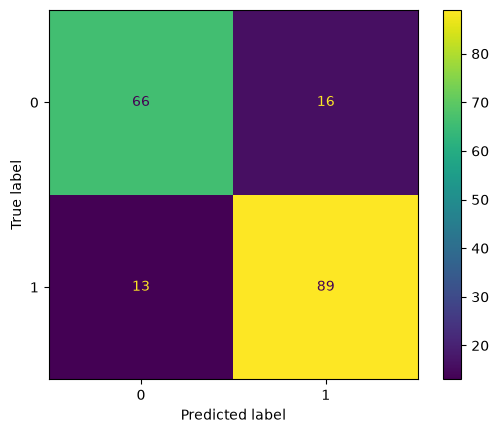

In [7]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

## 8. Classification Report

In [8]:
prediction = best_model.predict(X_test)
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



## 9. ROC Curve

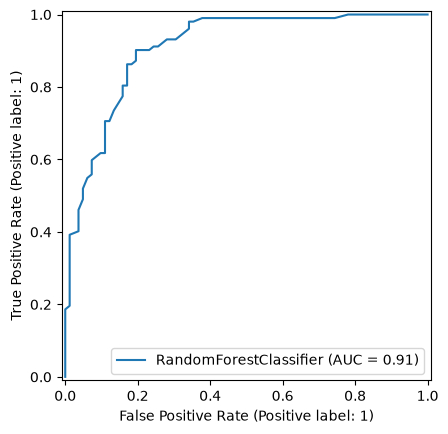

In [9]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

## 10. Save the Final Model

Only the model is saved here — the fitted preprocessing pipeline (`preprocessor.pkl`, imputer + scaler)

In [10]:
import joblib

joblib.dump(best_model, "../models/random_forest.pkl")
print("Saved random_forest.pkl")

Saved random_forest.pkl
